# POC: RLM vs RAG vs LLM — Long-Form Document Summarization
## Microsoft Q2 FY2026 Earnings Call Transcript  ·  3-Way Comparison

> **Hypothesis:** DSPy RLM achieves higher section recall and lower hallucination count than
> vanilla RAG on a long earnings call transcript, at the cost of higher latency and token spend.
> A full-context LLM baseline tests whether retrieval is even necessary when the document fits
> in the context window.

| Component | Choice |
|---|---|
| LLM (generation) | OpenAI `gpt-4o` |
| Embedding | IBM Granite `granite-embedding-125m-english` — local HuggingFace |
| Vector DB | FAISS (in-memory) |
| RLM Framework | DSPy `dspy.RLM` (GPT-4o root + GPT-4o-mini sub) |
| Transcript | MSFT Q2 FY2026 Earnings Call (~363 lines, real transcript) |

---

## Section 0 — Environment & Shared Clients
> Load API key, create shared OpenAI client, Granite embedder, tiktoken encoder, and DSPy LMs.

In [1]:
import os, sys, time, re, json, pathlib
import numpy as np

# ── Load API key from v2's .env ──────────────────────────────
env_path = pathlib.Path("../v2/.env")
if env_path.exists():
    with open(env_path) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip().strip('"').strip("'")

assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY not found — add it to Experiment/v2/.env"

# ── Ensure Deno is on PATH (required for DSPy RLM sandbox) ──
deno_dir = pathlib.Path.home() / ".deno" / "bin"
if deno_dir.exists() and str(deno_dir) not in os.environ.get("PATH", ""):
    os.environ["PATH"] = str(deno_dir) + os.pathsep + os.environ.get("PATH", "")
    print(f"✓ Added {deno_dir} to PATH")

import subprocess
deno_check = subprocess.run(["deno", "--version"], capture_output=True, text=True)
assert deno_check.returncode == 0, "Deno not found — install via: curl -fsSL https://deno.land/install.sh | sh"
print(f"✓ Deno available: {deno_check.stdout.splitlines()[0]}")

# ── Shared OpenAI client ─────────────────────────────────────
from openai import OpenAI
oai = OpenAI()
print("✓ OpenAI client ready")

# ── Shared tiktoken encoder ──────────────────────────────────
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")
print("✓ tiktoken encoder ready")

# ── Shared Granite embedding model ───────────────────────────
from sentence_transformers import SentenceTransformer

GRANITE_ID = "ibm-granite/granite-embedding-125m-english"
print(f"Loading {GRANITE_ID} ...")
granite = SentenceTransformer(GRANITE_ID)
test = granite.encode(["test"])
print(f"✓ Granite loaded  |  dim={test.shape[1]}  |  device={granite.device}")

# ── Shared DSPy LMs ──────────────────────────────────────────
import dspy
root_lm = dspy.LM(model="openai/gpt-4o",      temperature=0.1, cache=False)
sub_lm  = dspy.LM(model="openai/gpt-4o-mini", temperature=0.1, cache=False)
dspy.configure(lm=root_lm)
print("✓ DSPy configured")
print("  Root LM : openai/gpt-4o       (orchestration + generation)")
print("  Sub  LM : openai/gpt-4o-mini  (REPL sub-calls)")

✓ Deno available: deno 2.7.4 (stable, release, x86_64-pc-windows-msvc)


✓ OpenAI client ready
✓ tiktoken encoder ready


Loading ibm-granite/granite-embedding-125m-english ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✓ Granite loaded  |  dim=768  |  device=cpu


✓ DSPy configured
  Root LM : openai/gpt-4o       (orchestration + generation)
  Sub  LM : openai/gpt-4o-mini  (REPL sub-calls)


## Section 1 — Document Ingestion
Read the real MSFT Q2 FY2026 transcript from local file.

In [2]:
transcript_path = pathlib.Path("data/msft_ec.txt")
assert transcript_path.exists(), f"Transcript not found at {transcript_path}"

raw_text = transcript_path.read_text(encoding="utf-8")
TOTAL_DOC_TOKENS = len(enc.encode(raw_text))

print(f"Transcript : {transcript_path}")
print(f"Characters : {len(raw_text):,}")
print(f"Lines      : {raw_text.count(chr(10)):,}")
print(f"Tokens     : {TOTAL_DOC_TOKENS:,}  (cl100k_base)")
print(f"\nFirst 300 chars:\n{raw_text[:300]}")

Transcript : data\msft_ec.txt
Characters : 51,711
Lines      : 362
Tokens     : 10,954  (cl100k_base)

First 300 chars:
Microsoft FY26 Second Quarter Earnings Conference Call
Jonathan Neilson, Satya Nadella, Amy Hood
Wednesday January 28, 2026
JONATHAN NEILSON: 
Good afternoon and thank you for joining us today. On the call with me are Satya Nadella, chairman and chief executive officer, Amy Hood, chief financial off


## Section 2 — Ground Truth
Load comprehensive ground truth from JSON (31 revenue + 18 guidance + 9 risk + 8 analyst + 35 entities).

In [3]:
gt_path = pathlib.Path("data/ground_truth.json")
assert gt_path.exists(), f"Ground truth not found at {gt_path}"

with open(gt_path) as f:
    GROUND_TRUTH = json.load(f)

total_items = sum(len(v) for v in GROUND_TRUTH.values())
print(f"✓ Ground truth loaded from {gt_path}")
for k, v in GROUND_TRUTH.items():
    print(f"  {k:<25}: {len(v)} items")
print(f"  {'TOTAL':<25}: {total_items} items")

✓ Ground truth loaded from data\ground_truth.json
  revenue_figures          : 29 items
  guidance_statements      : 19 items
  risk_factors             : 9 items
  analyst_topics           : 8 items
  key_entities             : 37 items
  TOTAL                    : 102 items


## Section 3 — Metrics Infrastructure
`MetricsTracker` dataclass, `PRICES` dict, and `score_output()` function.

In [4]:
from dataclasses import dataclass, field
from typing import Dict, List

PRICES = {
    "gpt-4o":      {"input": 2.50,  "output": 10.00},
    "gpt-4o-mini": {"input": 0.15,  "output": 0.60},
}

@dataclass
class MetricsTracker:
    system_name: str
    start_time: float = field(default_factory=time.perf_counter)

    total_input_tokens:  int = 0
    total_output_tokens: int = 0
    embedding_tokens:    int = 0
    api_call_count:      int = 0
    model_calls:         Dict[str, int] = field(default_factory=dict)
    end_time:            float = 0.0
    first_output_time:   float = 0.0

    sections_populated:    List[str] = field(default_factory=list)
    revenue_figures_found: List[str] = field(default_factory=list)
    guidance_found:        List[str] = field(default_factory=list)
    entities_found:        List[str] = field(default_factory=list)
    hallucination_count:   int = 0
    repl_iterations:       int = 0
    sub_llm_calls:         int = 0
    code_strategies:       List[str] = field(default_factory=list)

    def log_api_call(self, model, input_tokens, output_tokens):
        self.total_input_tokens  += input_tokens
        self.total_output_tokens += output_tokens
        self.api_call_count      += 1
        self.model_calls[model]   = self.model_calls.get(model, 0) + 1

    def log_embedding(self, n):
        self.embedding_tokens += n

    def mark_first_output(self):
        if self.first_output_time == 0.0:
            self.first_output_time = time.perf_counter()

    def finish(self):
        self.end_time = time.perf_counter()

    @property
    def wall_clock_seconds(self):
        return (self.end_time or time.perf_counter()) - self.start_time

    @property
    def ttff_seconds(self):
        if self.first_output_time == 0.0:
            return self.wall_clock_seconds
        return self.first_output_time - self.start_time

    @property
    def estimated_cost_usd(self):
        cost = 0.0
        for model, price in PRICES.items():
            n = self.model_calls.get(model, 0)
            if n and self.api_call_count:
                frac = n / self.api_call_count
                cost += (self.total_input_tokens  * frac / 1e6 * price["input"] +
                         self.total_output_tokens * frac / 1e6 * price["output"])
        return cost

    @property
    def section_recall(self):
        return len(self.sections_populated)

    def summary_dict(self):
        return {
            "system":               self.system_name,
            "total_input_tokens":   self.total_input_tokens,
            "total_output_tokens":  self.total_output_tokens,
            "embedding_tokens":     self.embedding_tokens,
            "api_call_count":       self.api_call_count,
            "model_calls":          self.model_calls,
            "estimated_cost_usd":   round(self.estimated_cost_usd, 5),
            "wall_clock_s":         round(self.wall_clock_seconds, 2),
            "ttff_s":               round(self.ttff_seconds, 2),
            "section_recall_of_5":  self.section_recall,
            "sections_populated":   self.sections_populated,
            "revenue_recall_pct":   round(len(self.revenue_figures_found) /
                                          max(len(GROUND_TRUTH["revenue_figures"]), 1) * 100, 1),
            "guidance_recall_pct":  round(len(self.guidance_found) /
                                          max(len(GROUND_TRUTH["guidance_statements"]), 1) * 100, 1),
            "entity_recall_pct":    round(len(self.entities_found) /
                                          max(len(GROUND_TRUTH["key_entities"]), 1) * 100, 1),
            "hallucination_count":  self.hallucination_count,
            "repl_iterations":      self.repl_iterations,
            "sub_llm_calls":        self.sub_llm_calls,
            "code_strategies":      self.code_strategies,
        }

print("✓ MetricsTracker ready  (GPT-4o pricing: $2.50 in / $10 out per 1M)")

✓ MetricsTracker ready  (GPT-4o pricing: $2.50 in / $10 out per 1M)


In [5]:
def score_output(tracker, output, source_text):
    """Score pipeline output against loaded GROUND_TRUTH."""
    REQUIRED = ["executive_summary", "revenue_by_segment",
                "forward_guidance", "risk_factors", "analyst_qa_themes"]

    for sec in REQUIRED:
        if len(str(output.get(sec, "")).strip()) > 20:
            tracker.sections_populated.append(sec)

    out_text = json.dumps(output).lower()

    for key, value in GROUND_TRUTH["revenue_figures"].items():
        m = re.search(r"[\d.]+", value)
        if m and m.group() in out_text:
            tracker.revenue_figures_found.append(key)

    for stmt in GROUND_TRUTH["guidance_statements"]:
        nums = re.findall(r"[\d.]+", stmt)
        if any(n in out_text for n in nums if len(n) >= 2):
            tracker.guidance_found.append(stmt)

    for e in GROUND_TRUTH["key_entities"]:
        if e.lower() in out_text:
            tracker.entities_found.append(e)

    source_nums = set(re.findall(r"[\d.]+", source_text))
    claimed = re.findall(
        r"\$[\d.,]+[BMKbmk%]|[\d.,]+%|[\d.]+\s*(?:billion|percent|million)",
        json.dumps(output), re.I)
    tracker.hallucination_count = sum(
        1 for c in claimed
        for n in re.findall(r"[\d.]+", c)
        if len(n) >= 3 and n not in source_nums)
    return tracker

print("✓ score_output() defined")

✓ score_output() defined


## Section 4 — FAISS Index (shared for RAG)
**Granite embedding → FAISS IndexFlatIP**

In [6]:
import faiss

def chunk_text(text, chunk_size=512, overlap=50):
    tokens, chunks, step = enc.encode(text), [], chunk_size - overlap
    for start in range(0, len(tokens), step):
        chunks.append(enc.decode(tokens[start : start + chunk_size]))
        if start + chunk_size >= len(tokens):
            break
    return chunks

def build_faiss_index(chunks, embedder):
    print(f"  Embedding {len(chunks)} chunks...", end=" ", flush=True)
    embs = np.array(embedder.encode(chunks, show_progress_bar=False), dtype=np.float32)
    faiss.normalize_L2(embs)
    idx = faiss.IndexFlatIP(embs.shape[1])
    idx.add(embs)
    print(f"done  ({idx.ntotal} vectors x {embs.shape[1]} dims)")
    return idx

def retrieve(query, index, chunks, embedder, k=5):
    qv = np.array(embedder.encode([query], show_progress_bar=False), dtype=np.float32)
    faiss.normalize_L2(qv)
    _, idxs = index.search(qv, k)
    return [chunks[i] for i in idxs[0] if i < len(chunks)]

print("Building FAISS index from transcript...")
chunks      = chunk_text(raw_text)
faiss_index = build_faiss_index(chunks, granite)
EMB_TOKENS  = sum(len(enc.encode(c)) for c in chunks)
print(f"  Chunks           : {len(chunks)}")
print(f"  Embedding tokens : {EMB_TOKENS:,}  (local Granite, $0 cost)")

Building FAISS index from transcript...
  Embedding 24 chunks... 

done  (24 vectors x 768 dims)
  Chunks           : 24
  Embedding tokens : 12,104  (local Granite, $0 cost)


## Section 5 — RAG Pipeline
**Granite embedding → FAISS → GPT-4o**

In [7]:
RAG_QUERIES = {
    "executive_summary": (
        "Overall financial performance Q2 FY2026: total revenue, cloud revenue, "
        "operating income, net income, EPS, headline growth rates."
    ),
    "revenue_by_segment": (
        "All segment revenue figures and YoY growth: Azure, Intelligent Cloud, "
        "Productivity, Office 365, Dynamics, Dynamics 365, LinkedIn, More Personal "
        "Computing, Windows, Xbox, Surface, Search advertising."
    ),
    "forward_guidance": (
        "Q3 FY2026 guidance: revenue ranges for every segment, COGS, operating "
        "expenses, other income, effective tax rate, Azure constant-currency growth, FX impact."
    ),
    "risk_factors": (
        "Risks, headwinds, and challenges mentioned by management: macro, FX, "
        "AI capacity constraints, competition, regulatory scrutiny, CapEx concerns."
    ),
    "analyst_qa_themes": (
        "Analyst Q&A summary: each analyst name, firm, question topic, "
        "and key points from management response."
    ),
}

RAG_SYSTEM = (
    "You are a precise financial analyst assistant. Using ONLY the transcript "
    "context provided, answer fully and accurately. Include every number and "
    "percentage present in the context. If something is absent, write "
    "'Not found in retrieved chunks' — do not invent figures."
)

K = 5
rag_tracker = MetricsTracker("RAG  (Granite-FAISS + GPT-4o)")
rag_tracker.log_embedding(EMB_TOKENS)
rag_output  = {}

print(f"Running RAG  k={K}  across 5 sections...\n" + "-" * 60)

for section, query in RAG_QUERIES.items():
    t0 = time.perf_counter()
    retrieved = retrieve(query, faiss_index, chunks, granite, k=K)
    context   = "\n\n---\n\n".join(retrieved)
    rag_tracker.log_embedding(len(enc.encode(query)))

    resp = oai.chat.completions.create(
        model="gpt-4o",
        max_tokens=800,
        temperature=0.1,
        messages=[
            {"role": "system", "content": RAG_SYSTEM},
            {"role": "user",   "content": f"TRANSCRIPT CONTEXT:\n{context}\n\nQUESTION: {query}"},
        ],
    )
    answer = resp.choices[0].message.content
    rag_tracker.log_api_call("gpt-4o",
                              resp.usage.prompt_tokens,
                              resp.usage.completion_tokens)
    rag_output[section] = answer
    rag_tracker.mark_first_output()

    cov = len(retrieved) / len(chunks) * 100
    print(f"  [{section:<22}]  {time.perf_counter()-t0:5.1f}s  "
          f"|  {len(retrieved)}/{len(chunks)} chunks ({cov:.0f}% doc)  "
          f"|  {resp.usage.prompt_tokens}->{resp.usage.completion_tokens} tok")

rag_tracker.finish()
rag_tracker = score_output(rag_tracker, rag_output, raw_text)

rs = rag_tracker.summary_dict()
print("-" * 60)
print(f"✓ RAG done  {rs['wall_clock_s']:.1f}s  |  "
      f"{rs['total_input_tokens']:,} in  {rs['total_output_tokens']:,} out  |  "
      f"${rs['estimated_cost_usd']:.5f}  |  "
      f"sections {rs['section_recall_of_5']}/5  |  "
      f"revenue {rs['revenue_recall_pct']}%")

Running RAG  k=5  across 5 sections...
------------------------------------------------------------


  [executive_summary     ]    1.9s  |  5/24 chunks (21% doc)  |  2654->5 tok


  [revenue_by_segment    ]    3.8s  |  5/24 chunks (21% doc)  |  2665->243 tok


  [forward_guidance      ]    1.6s  |  5/24 chunks (21% doc)  |  2659->5 tok


  [risk_factors          ]    1.9s  |  5/24 chunks (21% doc)  |  2658->5 tok


  [analyst_qa_themes     ]    1.1s  |  5/24 chunks (21% doc)  |  2644->6 tok
------------------------------------------------------------
✓ RAG done  10.3s  |  13,280 in  264 out  |  $0.03584  |  sections 5/5  |  revenue 44.8%


In [8]:
print("\n" + "=" * 60 + "\n  RAG OUTPUT\n" + "=" * 60)
for sec, text in rag_output.items():
    print(f"\n> {sec.upper().replace('_', ' ')}:")
    t = str(text)
    print(t[:700] + (f"\n  ... [{len(t)-700} more chars]" if len(t) > 700 else ""))


  RAG OUTPUT

> EXECUTIVE SUMMARY:
Not found in retrieved chunks

> REVENUE BY SEGMENT:
- **Azure and other cloud services**: Revenue grew 39% and 38% in constant currency.
- **Intelligent Cloud segment**: Revenue was $32.9 billion, grew 29% and 28% in constant currency.
- **Productivity and Business Processes**: Revenue was $34.1 billion, grew 16% and 14% in constant currency.
- **M365 commercial cloud**: Revenue increased 17% and 14% in constant currency.
- **Dynamics 365**: Revenue increased 19% and 17% in constant currency.
- **LinkedIn**: Revenue increased 11% and 10% in constant currency.
- **More Personal Computing**: Revenue was $14.3 billion, declined 3%.
- **Windows OEM and Devices**: Revenue increased 1%, Windows OEM grew 5%.
- **Xbox content and services**: Revenue 
  ... [226 more chars]

> FORWARD GUIDANCE:
Not found in retrieved chunks

> RISK FACTORS:
Not found in retrieved chunks

> ANALYST QA THEMES:
Not found in retrieved chunks.


## Section 6 — LLM Pipeline (Full Context)
**Full transcript → GPT-4o** — 5 separate calls, one per section.

In [9]:
LLM_QUERIES = {
    "executive_summary": (
        "Provide a comprehensive executive summary of Q2 FY2026 financial performance: "
        "total revenue, cloud revenue, operating income, EPS, and all headline growth rates."
    ),
    "revenue_by_segment": (
        "List ALL segment revenue figures and YoY growth rates: Azure, Intelligent Cloud, "
        "Productivity and Business Processes, Office 365, Dynamics 365, LinkedIn, "
        "More Personal Computing, Windows, Xbox, Surface, Search advertising. "
        "Include every dollar figure and percentage mentioned."
    ),
    "forward_guidance": (
        "Extract ALL Q3 FY2026 guidance: revenue ranges for every segment, COGS, "
        "operating expenses, other income, effective tax rate, Azure constant-currency "
        "growth guidance, FX impact, and any full-year outlook statements."
    ),
    "risk_factors": (
        "Identify ALL risks, headwinds, and challenges mentioned: AI supply constraints, "
        "CapEx ROI concerns, OpenAI concentration, gaming impairment, memory pricing, "
        "FX impact, competition, regulatory."
    ),
    "analyst_qa_themes": (
        "Summarize the analyst Q&A: for each analyst, provide their name, firm, "
        "question topic, and key points from management's response."
    ),
}

LLM_SYSTEM = (
    "You are a precise financial analyst assistant. Using ONLY the full earnings call "
    "transcript provided, answer fully and accurately. Include every number and "
    "percentage present. If something is absent, write 'Not found in transcript' "
    "— do not invent figures."
)

llm_tracker = MetricsTracker("LLM  (GPT-4o Full Context)")
llm_output  = {}

print(f"Running LLM (full context)  across 5 sections...\n" + "-" * 60)

for section, query in LLM_QUERIES.items():
    t0 = time.perf_counter()
    resp = oai.chat.completions.create(
        model="gpt-4o",
        max_tokens=1000,
        temperature=0.1,
        messages=[
            {"role": "system", "content": LLM_SYSTEM},
            {"role": "user",   "content": f"FULL TRANSCRIPT:\n{raw_text}\n\nQUESTION: {query}"},
        ],
    )
    answer = resp.choices[0].message.content
    llm_tracker.log_api_call("gpt-4o",
                              resp.usage.prompt_tokens,
                              resp.usage.completion_tokens)
    llm_output[section] = answer
    llm_tracker.mark_first_output()

    print(f"  [{section:<22}]  {time.perf_counter()-t0:5.1f}s  "
          f"|  {resp.usage.prompt_tokens}->{resp.usage.completion_tokens} tok")

llm_tracker.finish()
llm_tracker = score_output(llm_tracker, llm_output, raw_text)

ms = llm_tracker.summary_dict()
print("-" * 60)
print(f"✓ LLM done  {ms['wall_clock_s']:.1f}s  |  "
      f"{ms['total_input_tokens']:,} in  {ms['total_output_tokens']:,} out  |  "
      f"${ms['estimated_cost_usd']:.5f}  |  "
      f"sections {ms['section_recall_of_5']}/5  |  "
      f"revenue {ms['revenue_recall_pct']}%")

Running LLM (full context)  across 5 sections...
------------------------------------------------------------


  [executive_summary     ]    4.1s  |  11027->320 tok


  [revenue_by_segment    ]    3.7s  |  11049->233 tok


  [forward_guidance      ]    4.2s  |  11042->332 tok


  [risk_factors          ]    4.8s  |  11033->280 tok


  [analyst_qa_themes     ]    8.6s  |  11025->585 tok
------------------------------------------------------------
✓ LLM done  25.4s  |  55,176 in  1,750 out  |  $0.15544  |  sections 5/5  |  revenue 79.3%


In [10]:
print("\n" + "=" * 60 + "\n  LLM OUTPUT\n" + "=" * 60)
for sec, text in llm_output.items():
    print(f"\n> {sec.upper().replace('_', ' ')}:")
    t = str(text)
    print(t[:700] + (f"\n  ... [{len(t)-700} more chars]" if len(t) > 700 else ""))


  LLM OUTPUT

> EXECUTIVE SUMMARY:
In Q2 FY2026, Microsoft reported strong financial performance with the following key metrics:

- **Total Revenue**: $81.3 billion, representing a growth of 17% year-over-year and 15% in constant currency.
- **Microsoft Cloud Revenue**: $51.5 billion, which grew by 26% year-over-year and 24% in constant currency.
- **Operating Income**: Increased by 21% year-over-year and 19% in constant currency.
- **Earnings Per Share (EPS)**: $4.14, an increase of 24% year-over-year and 21% in constant currency, when adjusted for the impact from the investment in OpenAI.

Additional headline growth rates include:
- Gross margin dollars increased by 16% year-over-year and 14% in constant currency.
- Company
  ... [744 more chars]

> REVENUE BY SEGMENT:
- **Azure and other cloud services**: Revenue grew 39% and 38% in constant currency.
- **Intelligent Cloud segment**: Revenue was $32.9 billion, grew 29% and 28% in constant currency.
- **Productivity and Business Pro

## Section 7 — RLM Pipeline (DSPy + GPT-4o / GPT-4o-mini)
The LLM writes Python code to explore the transcript in a sandbox. Root calls use GPT-4o; cheaper REPL sub-calls use GPT-4o-mini.

In [11]:
class EarningsSignature(dspy.Signature):
    """
    Analyze a Microsoft earnings call transcript using Python code in a REPL.
    Systematically search every section. Extract ALL financial figures,
    guidance numbers, risk statements, and Q&A themes. Do not skip any section.
    """
    transcript: str = dspy.InputField(
        desc="Full earnings call transcript text")
    task: str = dspy.InputField(
        desc="Extraction instructions")
    executive_summary: str = dspy.OutputField(
        desc="5-sentence overview: total revenue, cloud, operating income, EPS, growth rates")
    revenue_by_segment: str = dspy.OutputField(
        desc="ALL segments with exact $ and YoY %: Azure, Intelligent Cloud, Productivity, "
             "Office 365, Dynamics 365, LinkedIn, MPC, Xbox, Surface, Search")
    forward_guidance: str = dspy.OutputField(
        desc="ALL Q3 FY2026 guidance ranges per segment + COGS + OpEx + tax rate + FX impact")
    risk_factors: str = dspy.OutputField(
        desc="ALL risks and headwinds: capacity constraints, CapEx ROI, OpenAI concentration, "
             "gaming impairment, memory pricing, FX, competition")
    analyst_qa_themes: str = dspy.OutputField(
        desc="Each analyst exchange: name, firm, question, key answer points")

print("✓ EarningsSignature defined")

✓ EarningsSignature defined


In [12]:
RLM_TASK = """
Extract a complete structured summary from this Microsoft Q2 FY2026 earnings transcript.
Use Python code to:
  1. Search for segment names to locate relevant paragraphs
  2. Extract every dollar figure and percentage near each segment
  3. Find all guidance statements ('We expect...')
  4. Extract every risk/headwind mentioned
  5. Find the Q&A section and summarise each analyst exchange
  6. Search for CapEx figures, RPO, free cash flow, and other financial metrics

Use loops to scan the entire document. Include every number mentioned.
"""

rlm_tracker = MetricsTracker("RLM  (DSPy dspy.RLM + GPT-4o / GPT-4o-mini)")
t0 = time.perf_counter()

rlm_module = dspy.RLM(
    signature=EarningsSignature,
    max_iterations=15,
    max_llm_calls=40,
    sub_lm=sub_lm,
    verbose=True,
)

print(f"Running DSPy RLM on {TOTAL_DOC_TOKENS:,}-token transcript...\n" + "=" * 60)
rlm_result = rlm_module(transcript=raw_text, task=RLM_TASK)
t1 = time.perf_counter()

rlm_tracker.start_time        = t0
rlm_tracker.end_time          = t1
rlm_tracker.first_output_time = t1
print("=" * 60)
print(f"\n✓ RLM done in {t1 - t0:.1f}s")

Running DSPy RLM on 10,954-token transcript...


2026/03/09 23:22:54 INFO dspy.predict.rlm: RLM iteration 1/15
Reasoning: To begin the analysis of the Microsoft earnings call transcript, I need to first understand the structure and content of the transcript. The transcript is a large text document, so I will start by examining its initial portion to get a sense of its format and how the information is organized. This will help me identify where to look for specific sections such as financial figures, guidance statements, risk factors, and the Q&A section. 

I will print the first few hundred characters of the transcript to get an overview of its structure and see how the speakers and sections are introduced. This will guide me in developing a strategy to extract the required information systematically.
Code:
```python
# Print the first 1000 characters of the transcript to understand its structure
print(transcript[:1000])
```


2026/03/09 23:23:07 INFO dspy.predict.rlm: RLM iteration 2/15
Reasoning: The initial portion of the transcript provides an introduction to the participants and mentions the availability of additional financial documents on the Microsoft Investor Relations website. This suggests that the transcript is structured with an introduction, followed by prepared remarks, and possibly a Q&A section. 

To proceed, I need to identify the main sections of the transcript, such as the financial overview, guidance, risk factors, and the Q&A section. This will help me locate the specific information required for extraction. I will search for keywords that typically indicate the start of these sections, such as "financial results," "guidance," "risk," and "Q&A."

I will write a function to scan the transcript for these keywords and print the surrounding text to verify the structure and locate the sections.
Code:
```python
import re

# Define keywords to search for different sections
keywords = ["financi

2026/03/09 23:23:16 INFO dspy.predict.rlm: RLM iteration 3/15
Reasoning: The previous step successfully identified the locations of key sections within the transcript using keywords. This gives us a good starting point to extract detailed information from each section. The next step is to focus on extracting financial figures and guidance statements, as these are crucial for the executive summary and revenue by segment.

To achieve this, I will:
1. Extract paragraphs around the "financial results" and "guidance" keywords to capture relevant financial data and guidance statements.
2. Use regular expressions to identify and extract dollar figures, percentages, and guidance phrases from these sections.

This will help in building the executive summary and understanding the revenue by segment and forward guidance. I will start by extracting and printing the paragraphs around these keywords to ensure we capture the necessary context for financial figures and guidance statements.
Code:
```py

2026/03/09 23:23:23 INFO dspy.predict.rlm: RLM iteration 4/15
Reasoning: The previous step successfully extracted paragraphs around the "financial results" and "guidance" keywords. However, the extracted content is limited and doesn't seem to contain specific financial figures or detailed guidance statements. This suggests that the context size might need to be adjusted, or additional keywords might be necessary to capture more relevant information.

To proceed, I will:
1. Increase the context size to capture more surrounding text, which might include the detailed financial figures and guidance statements.
2. Use additional keywords related to financial metrics, such as "revenue," "earnings," "profit," "growth," "forecast," and "expect" to ensure we capture all relevant data.
3. Extract and print the paragraphs again to verify if we have captured the necessary information.

This approach will help ensure that we gather comprehensive data for the executive summary, revenue by segment, a

...

2026/03/09 23:24:05 INFO dspy.predict.rlm: RLM iteration 9/15
Reasoning: The extraction of risk factors still did not yield any results, indicating that the current approach may not be effectively capturing the relevant information. This could be due to the complexity of the language used in the transcript or the placement of risk discussions in sections not previously considered.

To improve the extraction of risk factors, I will:
1. Use the `llm_query` function to semantically analyze the transcript for risk-related content. This function can better understand the context and nuances of language, potentially identifying risk factors that are not explicitly stated with the keywords used.
2. Focus on sections of the transcript that are likely to contain risk discussions, such as the Q&A section or any part where future expectations are discussed.

This approach should help in identifying the risk factors mentioned in the transcript, which are crucial for constructing the risk factors s

2026/03/09 23:24:11 INFO dspy.predict.rlm: RLM iteration 10/15
Reasoning: The semantic analysis using `llm_query` did not yield the expected results because the prompt was not correctly formatted to include the transcript text. To properly utilize `llm_query`, I need to pass the transcript text along with the prompt to ensure the model has the necessary context to analyze.

I will correct this by including the transcript text in the query. This should allow the model to semantically analyze the transcript and extract risk factors, challenges, uncertainties, and headwinds.
Code:
```python
# Correctly format the prompt to include the transcript text for semantic analysis
risk_query_prompt = f"Identify and extract all risk factors, challenges, uncertainties, and headwinds mentioned in this transcript: {transcript}"
risk_factors_semantic = llm_query(risk_query_prompt)

# Print the extracted risk factors from semantic analysis
print("--- Extracted Risk Factors from Semantic Analysis ---")
p

2026/03/09 23:24:44 INFO dspy.predict.rlm: RLM iteration 11/15
Reasoning: The semantic analysis using `llm_query` successfully extracted a comprehensive list of risk factors, challenges, uncertainties, and headwinds from the transcript. This information is crucial for constructing the risk factors section.

Next, I need to focus on the Q&A section to extract and summarize the themes discussed during the analyst exchanges. This involves identifying the start and end of the Q&A section and then analyzing the content to extract key themes and topics discussed by the analysts and executives.

I will write a function to locate the Q&A section in the transcript, extract the relevant text, and then use `llm_query` to summarize the themes discussed in this section. This will help in constructing the analyst Q&A themes section.
Code:
```python
# Function to extract the Q&A section from the transcript

def extract_qa_section(transcript):
    # Find the start and end of the Q&A section
    start_

2026/03/09 23:25:08 INFO dspy.predict.rlm: RLM iteration 12/15
Reasoning: I have successfully extracted and summarized the key components needed for the structured summary of the Microsoft Q2 FY2026 earnings transcript. Here's a recap of what has been accomplished:

1. **Executive Summary**: Extracted financial figures and growth percentages to summarize the overall financial performance.
2. **Revenue by Segment**: Identified revenue figures and growth rates for different segments.
3. **Forward Guidance**: Extracted guidance statements indicating future expectations and forecasts.
4. **Risk Factors**: Used semantic analysis to identify and list risk factors, challenges, uncertainties, and headwinds.
5. **Analyst Q&A Themes**: Summarized the key themes and topics discussed during the Q&A session.

Now, I will compile these extracted insights into the final structured outputs and submit them using the `SUBMIT` function. This will include the executive summary, revenue by segment, forward


✓ RLM done in 139.9s


In [13]:
# ── Extract trajectory metrics ────────────────────────────────
trajectory = getattr(rlm_result, "trajectory", [])
rlm_tracker.repl_iterations = len(trajectory)

strategies, sub_calls = set(), 0
for step in trajectory:
    cs = str(step.get("code", "")) + str(step.get("observation", ""))
    if "llm_query" in cs:                                sub_calls += 1
    if re.search(r"re\.findall|re\.search", cs):         strategies.add("regex")
    if re.search(r"\.split|\[:\d", cs):                  strategies.add("slice")
    if re.search(r"for .+ in ", cs):                     strategies.add("loop/map")
    if re.search(r"sorted\(|max\(|sum\(", cs):           strategies.add("aggregate")
    if "if " in cs:                                      strategies.add("filter")

rlm_tracker.sub_llm_calls   = sub_calls
rlm_tracker.code_strategies = list(strategies)

# ── Token usage from DSPy LM history ─────────────────────────
captured = False
try:
    for lm_obj, model_str in [(root_lm, "gpt-4o"), (sub_lm, "gpt-4o-mini")]:
        for entry in (lm_obj.history or []):
            usage = entry.get("usage") or {}
            it = usage.get("prompt_tokens") or usage.get("input_tokens") or 0
            ot = usage.get("completion_tokens") or usage.get("output_tokens") or 0
            if it or ot:
                rlm_tracker.log_api_call(model_str, it, ot)
                captured = True
except Exception as e:
    print(f"  (History unavailable: {e})")

if not captured:
    n_root = max(len(trajectory), 2) + 1
    n_sub  = max(sub_calls, 3)
    rlm_tracker.log_api_call("gpt-4o",      n_root * 2000, n_root * 500)
    rlm_tracker.log_api_call("gpt-4o-mini", n_sub  * 1200, n_sub  * 300)
    print(f"  Token count estimated ({n_root} root + {n_sub} sub calls)")

rlm_output = {
    "executive_summary":  str(getattr(rlm_result, "executive_summary", "")  or ""),
    "revenue_by_segment": str(getattr(rlm_result, "revenue_by_segment", "") or ""),
    "forward_guidance":   str(getattr(rlm_result, "forward_guidance", "")   or ""),
    "risk_factors":       str(getattr(rlm_result, "risk_factors", "")       or ""),
    "analyst_qa_themes":  str(getattr(rlm_result, "analyst_qa_themes", "")  or ""),
}
rlm_tracker = score_output(rlm_tracker, rlm_output, raw_text)

ls = rlm_tracker.summary_dict()
print(f"  REPL iterations : {ls['repl_iterations']}")
print(f"  Sub-LLM calls   : {ls['sub_llm_calls']}")
print(f"  Strategies      : {ls['code_strategies']}")
print(f"  Total tokens    : {ls['total_input_tokens']:,} in / {ls['total_output_tokens']:,} out")
print(f"  Cost estimate   : ${ls['estimated_cost_usd']:.5f}")
print(f"  Sections        : {ls['section_recall_of_5']}/5  |  revenue {ls['revenue_recall_pct']}%")

  REPL iterations : 12
  Sub-LLM calls   : 3
  Strategies      : ['loop/map', 'filter', 'slice', 'regex']
  Total tokens    : 97,524 in / 5,677 out
  Cost estimate   : $0.25072
  Sections        : 5/5  |  revenue 44.8%


In [14]:
print("\n" + "=" * 60 + "\n  RLM OUTPUT\n" + "=" * 60)
for sec, text in rlm_output.items():
    print(f"\n> {sec.upper().replace('_', ' ')}:")
    t = str(text) if text else "(empty)"
    print(t[:700] + (f"\n  ... [{len(t)-700} more chars]" if len(t) > 700 else ""))


  RLM OUTPUT

> EXECUTIVE SUMMARY:
Microsoft reported strong financial performance in Q2 FY2026 with revenue of $81.3 billion, up 17% year-over-year. Earnings per share increased by 24%, driven by growth in the Microsoft Cloud, which surpassed $50 billion in revenue for the first time. The company continues to invest in AI and cloud infrastructure to fuel long-term growth.

> REVENUE BY SEGMENT:
1. Microsoft Cloud: $51.5 billion, up 26%.
2. Productivity and Business Processes: $34.1 billion, up 16%.
3. Intelligent Cloud: $34.1 billion, up 29%.
4. More Personal Computing: $12.3 billion, up 3%.

> FORWARD GUIDANCE:
Microsoft expects Q3 revenue growth to be driven by Azure, with anticipated growth between 37% and 38% in constant currency. The company projects continued growth in M365 commercial cloud and Dynamics 365, with revenue growth in the low-double digits for LinkedIn.

> RISK FACTORS:
1. Risks and uncertainties in forward-looking statements.
2. Supply constraints for Azure servic

## Section 8 — 3-Way Comparison Table

In [15]:
import pandas as pd

rs = rag_tracker.summary_dict()
ms = llm_tracker.summary_dict()
ls = rlm_tracker.summary_dict()

def w3(rag_v, llm_v, rlm_v, higher=True):
    """Pick winner across 3 pipelines."""
    vals = {"RAG": rag_v, "LLM": llm_v, "RLM": rlm_v}
    best = max(vals, key=vals.get) if higher else min(vals, key=vals.get)
    counts = list(vals.values())
    if counts.count(counts[0]) == 3:
        return "Tie"
    return f"{best} ✓"

rows = [
    ("─── TOKEN & COST ───────────────────", "", "", "", ""),
    ("Total Input Tokens",
     f"{rs['total_input_tokens']:,}", f"{ms['total_input_tokens']:,}",
     f"{ls['total_input_tokens']:,}",
     w3(rs['total_input_tokens'], ms['total_input_tokens'], ls['total_input_tokens'], False)),
    ("Total Output Tokens",
     f"{rs['total_output_tokens']:,}", f"{ms['total_output_tokens']:,}",
     f"{ls['total_output_tokens']:,}",
     w3(rs['total_output_tokens'], ms['total_output_tokens'], ls['total_output_tokens'], False)),
    ("Embedding Tokens (Granite, $0)",
     f"{rs['embedding_tokens']:,}", "0", "0", "LLM ✓"),
    ("LLM API Calls",
     str(rs['api_call_count']), str(ms['api_call_count']), str(ls['api_call_count']),
     w3(rs['api_call_count'], ms['api_call_count'], ls['api_call_count'], False)),
    ("Est. Cost USD",
     f"${rs['estimated_cost_usd']:.5f}", f"${ms['estimated_cost_usd']:.5f}",
     f"${ls['estimated_cost_usd']:.5f}",
     w3(rs['estimated_cost_usd'], ms['estimated_cost_usd'], ls['estimated_cost_usd'], False)),
    ("─── LATENCY ────────────────────────", "", "", "", ""),
    ("Wall Clock Time (s)",
     f"{rs['wall_clock_s']:.1f}", f"{ms['wall_clock_s']:.1f}", f"{ls['wall_clock_s']:.1f}",
     w3(rs['wall_clock_s'], ms['wall_clock_s'], ls['wall_clock_s'], False)),
    ("Time To First Field (s)",
     f"{rs['ttff_s']:.1f}", f"{ms['ttff_s']:.1f}", f"{ls['ttff_s']:.1f}",
     w3(rs['ttff_s'], ms['ttff_s'], ls['ttff_s'], False)),
    ("─── COVERAGE ───────────────────────", "", "", "", ""),
    ("Section Recall  (/ 5)",
     f"{rs['section_recall_of_5']} / 5", f"{ms['section_recall_of_5']} / 5",
     f"{ls['section_recall_of_5']} / 5",
     w3(rs['section_recall_of_5'], ms['section_recall_of_5'], ls['section_recall_of_5'])),
    ("Revenue Figure Recall (%)",
     f"{rs['revenue_recall_pct']}%", f"{ms['revenue_recall_pct']}%",
     f"{ls['revenue_recall_pct']}%",
     w3(rs['revenue_recall_pct'], ms['revenue_recall_pct'], ls['revenue_recall_pct'])),
    ("Guidance Statement Recall (%)",
     f"{rs['guidance_recall_pct']}%", f"{ms['guidance_recall_pct']}%",
     f"{ls['guidance_recall_pct']}%",
     w3(rs['guidance_recall_pct'], ms['guidance_recall_pct'], ls['guidance_recall_pct'])),
    ("Named Entity Recall (%)",
     f"{rs['entity_recall_pct']}%", f"{ms['entity_recall_pct']}%",
     f"{ls['entity_recall_pct']}%",
     w3(rs['entity_recall_pct'], ms['entity_recall_pct'], ls['entity_recall_pct'])),
    ("─── QUALITY ────────────────────────", "", "", "", ""),
    ("Hallucination Count  (lower = better)",
     str(rs['hallucination_count']), str(ms['hallucination_count']),
     str(ls['hallucination_count']),
     w3(rs['hallucination_count'], ms['hallucination_count'], ls['hallucination_count'], False)),
    ("─── RLM OBSERVABILITY ──────────────", "", "", "", ""),
    ("REPL Iterations",   "N/A", "N/A", str(ls['repl_iterations']),  "—"),
    ("Sub-LLM Calls",     "N/A", "N/A", str(ls['sub_llm_calls']),    "—"),
    ("Code Strategies",   "N/A", "N/A", ", ".join(ls['code_strategies']) or "N/A", "—"),
]

df = pd.DataFrame(rows, columns=[
    "Metric",
    "RAG  (Granite+FAISS+GPT-4o)",
    "LLM  (GPT-4o Full Context)",
    "RLM  (DSPy+GPT-4o/GPT-4o-mini)",
    "Winner",
])

def style_df(df):
    def row_style(row):
        s = [""] * len(row)
        label = str(row.iloc[0])
        wval  = str(row.iloc[-1])
        if label.startswith("─"):
            return ["background:#1e3a5f;color:#94c3d8;font-weight:bold"] * len(row)
        if "RAG ✓" in wval: s[-1] = "background:#cffafe;font-weight:bold;color:#155e75"
        if "LLM ✓" in wval: s[-1] = "background:#d1fae5;font-weight:bold;color:#065f46"
        if "RLM ✓" in wval: s[-1] = "background:#ede9fe;font-weight:bold;color:#5b21b6"
        return s

    return (df.style
              .apply(row_style, axis=1)
              .hide(axis="index")
              .set_table_styles([
                  {"selector": "th", "props": [("background", "#0f1f3d"), ("color", "#f1f5f9"),
                                                ("font-weight", "bold"), ("padding", "8px 12px")]},
                  {"selector": "td", "props": [("padding", "6px 12px"),
                                                ("border", "1px solid #e2e8f0")]},
              ]))

display(style_df(df))

Metric,RAG (Granite+FAISS+GPT-4o),LLM (GPT-4o Full Context),RLM (DSPy+GPT-4o/GPT-4o-mini),Winner
─── TOKEN & COST ───────────────────,,,,
Total Input Tokens,"13,280","55,176","97,524",RAG ✓
Total Output Tokens,264,"1,750","5,677",RAG ✓
"Embedding Tokens (Granite, $0)","12,260",0,0,LLM ✓
LLM API Calls,5,5,17,RAG ✓
Est. Cost USD,$0.03584,$0.15544,$0.25072,RAG ✓
─── LATENCY ────────────────────────,,,,
Wall Clock Time (s),10.3,25.4,139.9,RAG ✓
Time To First Field (s),1.9,4.1,139.9,RAG ✓
─── COVERAGE ───────────────────────,,,,


## Section 9 — Charts
3-bar grouped charts: RAG (cyan) vs LLM (green) vs RLM (purple).

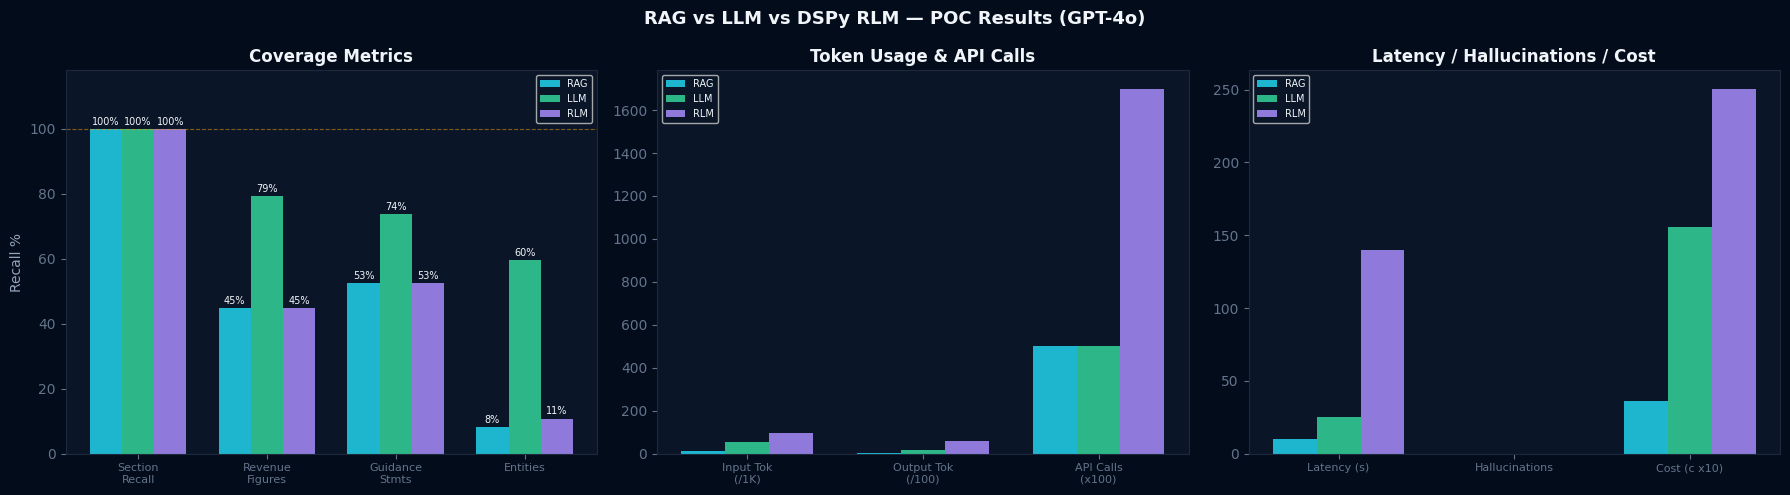

✓ Chart saved -> rag_vs_llm_vs_rlm_results.png


In [16]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.facecolor": "#020c1b", "axes.facecolor": "#0a1628",
    "axes.edgecolor": "#1e293b",   "axes.labelcolor": "#94a3b8",
    "xtick.color": "#64748b",      "ytick.color": "#64748b",
    "text.color": "#f1f5f9",       "grid.color": "#1e293b",
})

RC, GC, LC = "#22d3ee", "#34d399", "#a78bfa"   # RAG=cyan, LLM=green, RLM=purple
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("RAG vs LLM vs DSPy RLM — POC Results (GPT-4o)",
             color="#f1f5f9", fontsize=13, fontweight="bold")

rs = rag_tracker.summary_dict()
ms = llm_tracker.summary_dict()
ls = rlm_tracker.summary_dict()
w2 = 0.25

# ── Panel 1: Coverage ────────────────────────────────────────
ax = axes[0]
cats = ["Section\nRecall", "Revenue\nFigures", "Guidance\nStmts", "Entities"]
rv = [rs["section_recall_of_5"]/5*100, rs["revenue_recall_pct"],
      rs["guidance_recall_pct"],         rs["entity_recall_pct"]]
mv = [ms["section_recall_of_5"]/5*100, ms["revenue_recall_pct"],
      ms["guidance_recall_pct"],         ms["entity_recall_pct"]]
lv = [ls["section_recall_of_5"]/5*100, ls["revenue_recall_pct"],
      ls["guidance_recall_pct"],         ls["entity_recall_pct"]]
x  = np.arange(len(cats))
b1 = ax.bar(x - w2, rv, w2, label="RAG", color=RC, alpha=0.85)
b2 = ax.bar(x,      mv, w2, label="LLM", color=GC, alpha=0.85)
b3 = ax.bar(x + w2, lv, w2, label="RLM", color=LC, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats, fontsize=8)
ax.set_ylim(0, 118); ax.set_ylabel("Recall %")
ax.set_title("Coverage Metrics", color="#f1f5f9", fontweight="bold")
ax.legend(fontsize=7)
ax.axhline(100, color="#f59e0b", ls="--", lw=0.8, alpha=0.5)
for b in list(b1) + list(b2) + list(b3):
    h = b.get_height()
    ax.annotate(f"{h:.0f}%", xy=(b.get_x() + b.get_width()/2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=7, color="#f1f5f9")

# ── Panel 2: Token Usage ─────────────────────────────────────
ax2 = axes[1]
tcats = ["Input Tok\n(/1K)", "Output Tok\n(/100)", "API Calls\n(x100)"]
rtv = [rs["total_input_tokens"]/1000, rs["total_output_tokens"]/100,
       rs["api_call_count"] * 100]
mtv = [ms["total_input_tokens"]/1000, ms["total_output_tokens"]/100,
       ms["api_call_count"] * 100]
ltv = [ls["total_input_tokens"]/1000, ls["total_output_tokens"]/100,
       ls["api_call_count"] * 100]
x2 = np.arange(len(tcats))
ax2.bar(x2 - w2, rtv, w2, label="RAG", color=RC, alpha=0.85)
ax2.bar(x2,      mtv, w2, label="LLM", color=GC, alpha=0.85)
ax2.bar(x2 + w2, ltv, w2, label="RLM", color=LC, alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(tcats, fontsize=8)
ax2.set_title("Token Usage & API Calls", color="#f1f5f9", fontweight="bold")
ax2.legend(fontsize=7)

# ── Panel 3: Latency / Hallucinations / Cost ─────────────────
ax3 = axes[2]
lcats = ["Latency (s)", "Hallucinations", "Cost (c x10)"]
rlv = [rs["wall_clock_s"], rs["hallucination_count"],
       rs["estimated_cost_usd"] * 1000]
mlv = [ms["wall_clock_s"], ms["hallucination_count"],
       ms["estimated_cost_usd"] * 1000]
llv = [ls["wall_clock_s"], ls["hallucination_count"],
       ls["estimated_cost_usd"] * 1000]
x3 = np.arange(len(lcats))
ax3.bar(x3 - w2, rlv, w2, label="RAG", color=RC, alpha=0.85)
ax3.bar(x3,      mlv, w2, label="LLM", color=GC, alpha=0.85)
ax3.bar(x3 + w2, llv, w2, label="RLM", color=LC, alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(lcats, fontsize=8)
ax3.set_title("Latency / Hallucinations / Cost", color="#f1f5f9", fontweight="bold")
ax3.legend(fontsize=7)

plt.tight_layout()
plt.savefig("rag_vs_llm_vs_rlm_results.png", dpi=150, bbox_inches="tight", facecolor="#020c1b")
plt.show()
print("✓ Chart saved -> rag_vs_llm_vs_rlm_results.png")

In [17]:
from IPython.display import HTML, display

SECTIONS = [
    ("executive_summary",  "S1 — Executive Summary"),
    ("revenue_by_segment", "S2 — Revenue by Segment"),
    ("forward_guidance",   "S3 — Forward Guidance"),
    ("risk_factors",       "S4 — Risk Factors"),
    ("analyst_qa_themes",  "S5 — Analyst Q&A Themes"),
]

def fmt(text, populated):
    s = str(text).strip() if text else ""
    if len(s) < 20:
        return '<span style="color:#ef4444;font-style:italic">Not populated</span>'
    icon  = "OK" if populated else "??"
    color = "#16a34a" if populated else "#f59e0b"
    preview = s[:500].replace("\n", "<br>")
    suffix = (f'<br><span style="color:#64748b;font-size:11px">'
              f'[+{len(s)-500} chars]</span>' if len(s) > 500 else "")
    return f'<span style="color:{color};font-weight:bold">{icon}</span> {preview}{suffix}'

html = [
    '<style>'
    '.dt{width:100%;border-collapse:collapse;font-family:Arial,sans-serif;font-size:12px}'
    '.dt th{background:#1e3a5f;color:#fff;padding:6px 10px;text-align:left}'
    '.dt td{padding:6px 10px;vertical-align:top;border:1px solid #e2e8f0}'
    '.sl{background:#0f1f3d;color:#22d3ee;font-weight:bold;white-space:nowrap}'
    '.rc{border-left:3px solid #22d3ee}'
    '.gc{border-left:3px solid #34d399}'
    '.lc{border-left:3px solid #a78bfa}'
    '</style>'
    '<table class="dt"><tr>'
    '<th style="width:12%">Section</th>'
    '<th class="rc" style="width:29%">RAG  (Granite+FAISS+GPT-4o)</th>'
    '<th class="gc" style="width:29%">LLM  (GPT-4o Full Context)</th>'
    '<th class="lc" style="width:30%">RLM  (DSPy+GPT-4o/4o-mini)</th>'
    '</tr>',
]

for key, label in SECTIONS:
    rag_pop = key in rag_tracker.sections_populated
    llm_pop = key in llm_tracker.sections_populated
    rlm_pop = key in rlm_tracker.sections_populated
    row = (f'<tr><td class="sl">{label}</td>'
           f'<td class="rc">{fmt(rag_output.get(key, ""), rag_pop)}</td>'
           f'<td class="gc">{fmt(llm_output.get(key, ""), llm_pop)}</td>'
           f'<td class="lc">{fmt(rlm_output.get(key, ""), rlm_pop)}</td></tr>')
    html.append(row)

html.append("</table>")
display(HTML("".join(html)))

Section,RAG (Granite+FAISS+GPT-4o),LLM (GPT-4o Full Context),RLM (DSPy+GPT-4o/4o-mini)
S1 — Executive Summary,OK Not found in retrieved chunks,"OK In Q2 FY2026, Microsoft reported strong financial performance with the following key metrics:- **Total Revenue**: $81.3 billion, representing a growth of 17% year-over-year and 15% in constant currency.- **Microsoft Cloud Revenue**: $51.5 billion, which grew by 26% year-over-year and 24% in constant currency.- **Operating Income**: Increased by 21% year-over-year and 19% in constant currency.- **Earnings Per Share (EPS)**: $4.14, an increase of 24% year-over-year and 21% in constant currenc[+944 chars]","OK Microsoft reported strong financial performance in Q2 FY2026 with revenue of $81.3 billion, up 17% year-over-year. Earnings per share increased by 24%, driven by growth in the Microsoft Cloud, which surpassed $50 billion in revenue for the first time. The company continues to invest in AI and cloud infrastructure to fuel long-term growth."
S2 — Revenue by Segment,"OK - **Azure and other cloud services**: Revenue grew 39% and 38% in constant currency.- **Intelligent Cloud segment**: Revenue was $32.9 billion, grew 29% and 28% in constant currency.- **Productivity and Business Processes**: Revenue was $34.1 billion, grew 16% and 14% in constant currency.- **M365 commercial cloud**: Revenue increased 17% and 14% in constant currency.- **Dynamics 365**: Revenue increased 19% and 17% in constant currency.- **LinkedIn**: Revenue increased 11% and 10% in const[+426 chars]","OK - **Azure and other cloud services**: Revenue grew 39% and 38% in constant currency.- **Intelligent Cloud segment**: Revenue was $32.9 billion, grew 29% and 28% in constant currency.- **Productivity and Business Processes**: Revenue was $34.1 billion, grew 16% and 14% in constant currency.- **M365 commercial cloud**: Revenue increased 17% and 14% in constant currency.- **Dynamics 365**: Revenue increased 19% and 17% in constant currency.- **LinkedIn**: Revenue increased 11% and 10% in const[+394 chars]","OK 1. Microsoft Cloud: $51.5 billion, up 26%.2. Productivity and Business Processes: $34.1 billion, up 16%.3. Intelligent Cloud: $34.1 billion, up 29%.4. More Personal Computing: $12.3 billion, up 3%."
S3 — Forward Guidance,OK Not found in retrieved chunks,"OK **Q3 FY2026 Guidance:**- **Total Company Revenue:** $80.65 to $81.75 billion, growth of 15% to 17%.- **COGS (Cost of Goods Sold):** $26.65 to $26.85 billion, growth of 22% to 23%.- **Operating Expenses:** $17.8 to $17.9 billion, growth of 10% to 11%.- **Other Income and Expense:** Expected to be roughly $700 million.- **Effective Tax Rate:** Approximately 19%.**Segment Revenue Guidance:**- **Productivity and Business Processes:** $34.25 to $34.55 billion, growth of 14% to 15%.- **Inte[+761 chars]","OK Microsoft expects Q3 revenue growth to be driven by Azure, with anticipated growth between 37% and 38% in constant currency. The company projects continued growth in M365 commercial cloud and Dynamics 365, with revenue growth in the low-double digits for LinkedIn."
S4 — Risk Factors,OK Not found in retrieved chunks,"OK The transcript mentions the following risks, headwinds, and challenges:1. **AI Supply Constraints**: There is a mention of demand exceeding supply, particularly in Azure, and the need to balance incoming supply with expanding first-party AI usage and R&D allocations.2. **CapEx ROI Concerns**: There are concerns about the return on investment for capital expenditures, particularly in relation to Azure growth and the allocation of GPUs and CPUs.3. **OpenAI Concentration**: There is a signifi[+918 chars]","OK 1. Risks and uncertainties in forward-looking statements.2. Supply constraints for Azure services and AI workloads.3. Impact of AI infrastructure investments on gross margins.4. Concerns about CapEx growth and ROI.5. Volatility in revenue recognition due to OpenAI contracts.6. Market dynamics, including increased memory pricing.7. Execution cha

## Section 10 — Verdict & Persist
3-way composite scoring, hypothesis verdict, and result persistence.

In [18]:
rs = rag_tracker.summary_dict()
ms = llm_tracker.summary_dict()
ls = rlm_tracker.summary_dict()

def composite(s):
    return (s["section_recall_of_5"]     * 2.0 +
            s["revenue_recall_pct"]/100  * 1.5 +
            s["guidance_recall_pct"]/100 * 1.5 +
            s["entity_recall_pct"]/100   * 0.5 -
            min(s["hallucination_count"], 10) * 0.3)

rag_score = composite(rs)
llm_score = composite(ms)
rlm_score = composite(ls)
scores = {"RAG": rag_score, "LLM": llm_score, "RLM": rlm_score}
best = max(scores, key=scores.get)

print("\n" + "=" * 62)
print("  3-WAY HYPOTHESIS VERDICT")
print("=" * 62)
print(f"\n  Composite accuracy  RAG : {rag_score:.2f}")
print(f"  Composite accuracy  LLM : {llm_score:.2f}")
print(f"  Composite accuracy  RLM : {rlm_score:.2f}")
print(f"\n  Best pipeline: {best}  ({scores[best]:.2f})")
print()

if rlm_score > rag_score:
    lat  = ls['wall_clock_s']       / max(rs['wall_clock_s'], 0.1)
    cost = ls['estimated_cost_usd'] / max(rs['estimated_cost_usd'], 1e-6)
    print(f"  RLM outperforms RAG on accuracy  ({rlm_score:.2f} vs {rag_score:.2f})")
    print(f"  at {lat:.1f}x latency and {cost:.1f}x cost.")
else:
    print(f"  RAG outperforms RLM on accuracy  ({rag_score:.2f} vs {rlm_score:.2f})")

if llm_score >= rag_score and llm_score >= rlm_score:
    print(f"\n  LLM (full context) achieves the best composite score ({llm_score:.2f}).")
    print("  Full context beats retrieval when the document fits in the context window.")

print()
print("  PIPELINE RECOMMENDATIONS:")
print("  +-- RAG  ->  real-time user Q&A  (latency-critical, cost-efficient)")
print("  +-- LLM  ->  single-doc analysis  (when doc fits in context window)")
print("  +-- RLM  ->  multi-doc batch      (completeness-critical, complex reasoning)")
print()
print(f"  Section recall  RAG {rs['section_recall_of_5']}/5  "
      f"LLM {ms['section_recall_of_5']}/5  "
      f"RLM {ls['section_recall_of_5']}/5")
print(f"  Revenue recall  RAG {rs['revenue_recall_pct']}%  "
      f"LLM {ms['revenue_recall_pct']}%  "
      f"RLM {ls['revenue_recall_pct']}%")
print(f"  Hallucinations  RAG {rs['hallucination_count']}  "
      f"LLM {ms['hallucination_count']}  "
      f"RLM {ls['hallucination_count']}")
print(f"  Latency         RAG {rs['wall_clock_s']:.1f}s  "
      f"LLM {ms['wall_clock_s']:.1f}s  "
      f"RLM {ls['wall_clock_s']:.1f}s")
print(f"  Cost            RAG ${rs['estimated_cost_usd']:.5f}  "
      f"LLM ${ms['estimated_cost_usd']:.5f}  "
      f"RLM ${ls['estimated_cost_usd']:.5f}")
print("=" * 62)


  3-WAY HYPOTHESIS VERDICT

  Composite accuracy  RAG : 11.50
  Composite accuracy  LLM : 12.59
  Composite accuracy  RLM : 11.52

  Best pipeline: LLM  (12.59)

  RLM outperforms RAG on accuracy  (11.52 vs 11.50)
  at 13.6x latency and 7.0x cost.

  LLM (full context) achieves the best composite score (12.59).
  Full context beats retrieval when the document fits in the context window.

  PIPELINE RECOMMENDATIONS:
  +-- RAG  ->  real-time user Q&A  (latency-critical, cost-efficient)
  +-- LLM  ->  single-doc analysis  (when doc fits in context window)
  +-- RLM  ->  multi-doc batch      (completeness-critical, complex reasoning)

  Section recall  RAG 5/5  LLM 5/5  RLM 5/5
  Revenue recall  RAG 44.8%  LLM 79.3%  RLM 44.8%
  Hallucinations  RAG 0  LLM 0  RLM 0
  Latency         RAG 10.3s  LLM 25.4s  RLM 139.9s
  Cost            RAG $0.03584  LLM $0.15544  RLM $0.25072


In [19]:
results = {
    "rag": rag_tracker.summary_dict(),
    "llm": llm_tracker.summary_dict(),
    "rlm": rlm_tracker.summary_dict(),
    "rag_output": rag_output,
    "llm_output": llm_output,
    "rlm_output": rlm_output,
}
with open("poc_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✓ poc_results.json saved")
print("✓ rag_vs_llm_vs_rlm_results.png saved")

✓ poc_results.json saved
✓ rag_vs_llm_vs_rlm_results.png saved
